In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [6]:
df = pd.read_csv('C:\\Users\\Lenovo\\Downloads\\Titanic-Dataset.csv')
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns\n")

Shape: 891 rows × 12 columns



Data Overview

In [7]:
print("\nDataset Dimensions:")
print(df.shape)


Dataset Dimensions:
(891, 12)


In [8]:
print("\nColumn Information:")
df.info()


Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [9]:
print("\nFirst 5 Rows:")
print(df.head())


First 5 Rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   Na

In [10]:
print("\nData Types:")
print(df.dtypes)


Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [17]:
# ============================================================
# SECTION 2: MISSING VALUES ANALYSIS
# ============================================================

def analyze_missing_values(df):
    print("MISSING VALUES ANALYSIS")
    missing_count = df.isnull().sum()

    missing_percent = (
        df.isnull().sum() / len(df)
    ) * 100


    missing_df = pd.DataFrame({
        "Column": df.columns,
        "Missing_Count": missing_count.values,
        "Missing_Percent": missing_percent.values,
        "Data_Type": df.dtypes.values
    })


    missing_summary = (
        missing_df[
            missing_df["Missing_Count"] > 0
        ]
        .sort_values(
            "Missing_Count",
            ascending=False
        )
    )


    print("\nColumns with Missing Values:")
    print(
        missing_summary.to_string(index=False)
    )


    print("\nMissing Value Statistics:")
    print(
        f"Total Missing Values: {missing_count.sum()}"
    )

    print(
        f"Columns With Missing Data: {(missing_count > 0).sum()}"
    )

    print(
        f"Columns Without Missing Data: {(missing_count == 0).sum()}"
    )


    return missing_df

output = analyze_missing_values(df)
print(output)
    

MISSING VALUES ANALYSIS

Columns with Missing Values:
  Column  Missing_Count  Missing_Percent Data_Type
   Cabin            687        77.104377    object
     Age            177        19.865320   float64
Embarked              2         0.224467    object

Missing Value Statistics:
Total Missing Values: 866
Columns With Missing Data: 3
Columns Without Missing Data: 9
         Column  Missing_Count  Missing_Percent Data_Type
0   PassengerId              0         0.000000     int64
1      Survived              0         0.000000     int64
2        Pclass              0         0.000000     int64
3          Name              0         0.000000    object
4           Sex              0         0.000000    object
5           Age            177        19.865320   float64
6         SibSp              0         0.000000     int64
7         Parch              0         0.000000     int64
8        Ticket              0         0.000000    object
9          Fare              0         0.000000 


Displaying missing value chart...


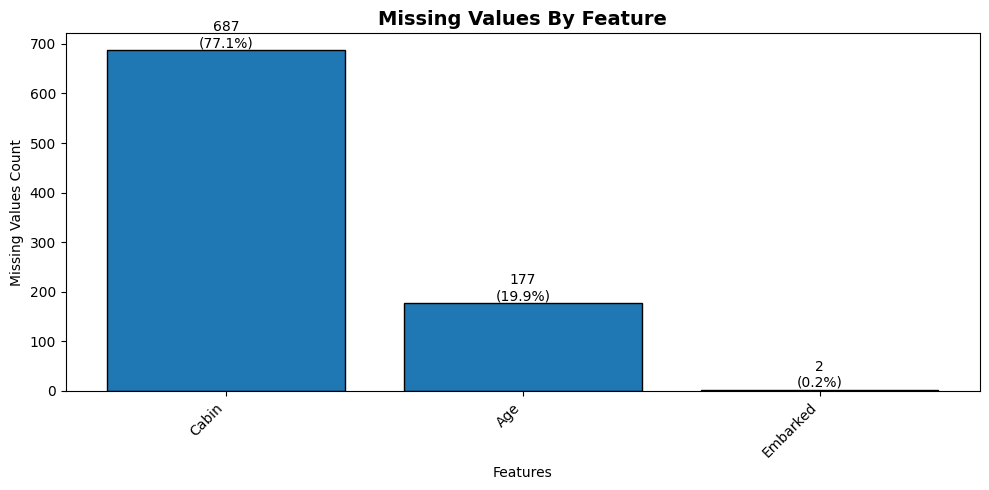

None


In [18]:
def visualize_missing_values(df):
    

    print("\nDisplaying missing value chart...")


    missing_data = df.isnull().sum()

    missing_percent = (
        missing_data / len(df)
    ) * 100


    missing_data = (
        missing_data[
            missing_data > 0
        ]
        .sort_values(
            ascending=False
        )
    )


    missing_percent = (
        missing_percent[
            missing_percent > 0
        ]
        .sort_values(
            ascending=False
        )
    )


    fig, ax = plt.subplots(
        figsize=(10,5)
    )


    bars = ax.bar(
        range(len(missing_data)),
        missing_data.values,
        edgecolor="black"
    )


    ax.set_xticks(
        range(len(missing_data))
    )

    ax.set_xticklabels(
        missing_data.index,
        rotation=45,
        ha="right"
    )


    ax.set_xlabel("Features")
    ax.set_ylabel("Missing Values Count")

    ax.set_title(
        "Missing Values By Feature",
        fontsize=14,
        fontweight="bold"
    )


    for i, bar in enumerate(bars):

        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"{int(height)}\n({missing_percent.values[i]:.1f}%)",
            ha="center",
            va="bottom"
        )


    plt.tight_layout()

    # Display only (no saving)
    plt.show()

    plt.close()
output = visualize_missing_values(df)
print(output)

In [20]:
def analyze_distributions(df):
    print("DISTRIBUTION ANALYSIS")

    print("\nNumerical Features Statistics:")
    print(df.describe())

    print("\nCategorical Features Distribution:")

    categorical_cols = df.select_dtypes(
        include=['object']
    ).columns

    for col in categorical_cols:

        print(f"\n{col}:")
        print(
            df[col].value_counts(
                dropna=False
            )
        )

output = analyze_distributions(df)
print(output)

DISTRIBUTION ANALYSIS

Numerical Features Statistics:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  

Categorical Features Distr


Displaying histograms...


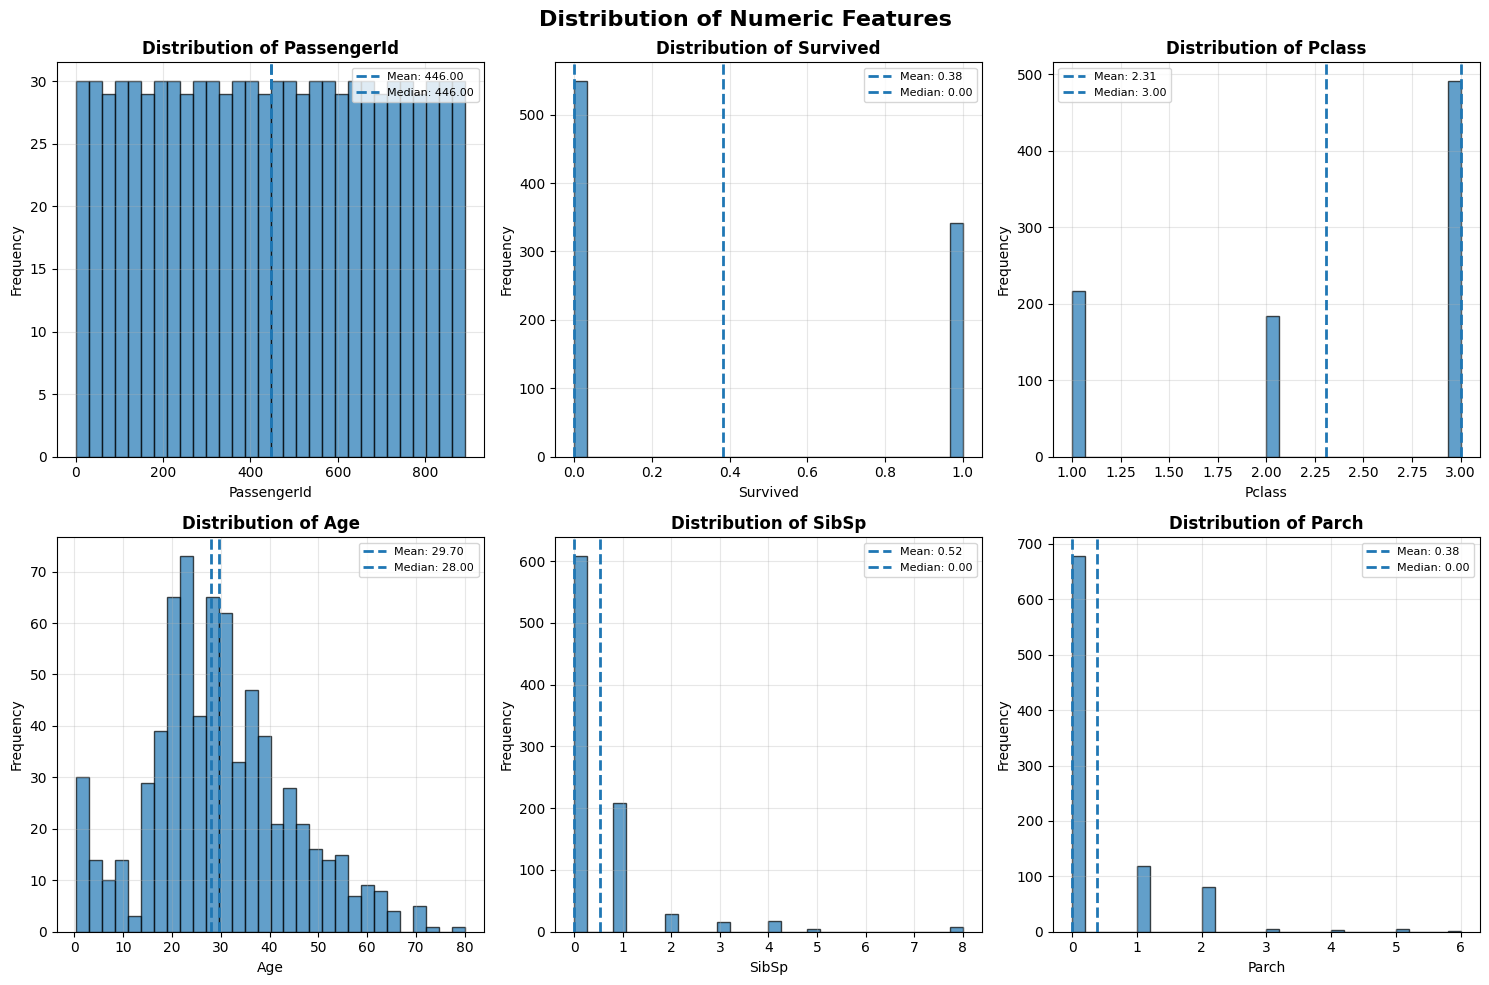

None


In [21]:
def create_histograms(df):
    print("\nDisplaying histograms...")


    numeric_cols = df.select_dtypes(
        include=[np.number]
    ).columns


    fig, axes = plt.subplots(
        2,
        3,
        figsize=(15,10)
    )


    axes = axes.flatten()


    for idx, col in enumerate(numeric_cols):

        if idx < len(axes):

            ax = axes[idx]


            ax.hist(
                df[col].dropna(),
                bins=30,
                edgecolor="black",
                alpha=0.7
            )


            ax.set_title(
                f"Distribution of {col}",
                fontsize=12,
                fontweight="bold"
            )


            ax.set_xlabel(col)

            ax.set_ylabel(
                "Frequency"
            )


            ax.grid(
                alpha=0.3
            )


            mean_value = df[col].mean()

            median_value = df[col].median()


            ax.axvline(
                mean_value,
                linestyle="--",
                linewidth=2,
                label=f"Mean: {mean_value:.2f}"
            )


            ax.axvline(
                median_value,
                linestyle="--",
                linewidth=2,
                label=f"Median: {median_value:.2f}"
            )


            ax.legend(
                fontsize=8
            )

    for idx in range(
        len(numeric_cols),
        len(axes)
    ):

        fig.delaxes(
            axes[idx]
        )


    plt.suptitle(
        "Distribution of Numeric Features",
        fontsize=16,
        fontweight="bold"
    )


    plt.tight_layout()

 
    plt.show()

    plt.close()

print(create_histograms(df))


Displaying categorical distributions...


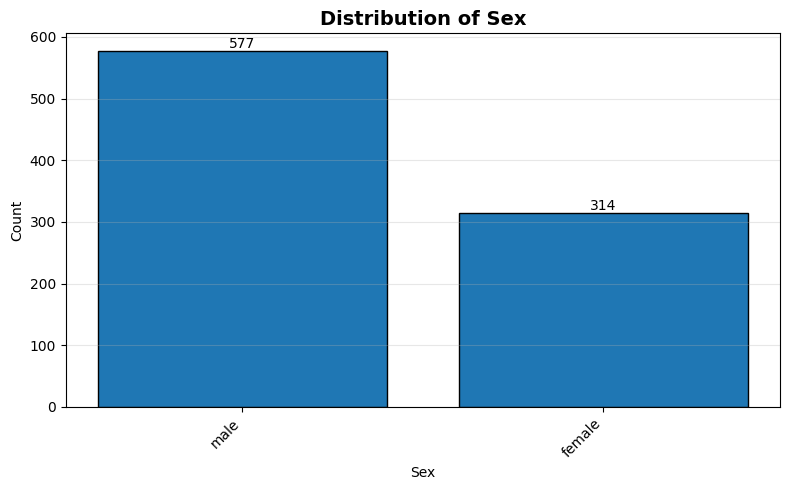

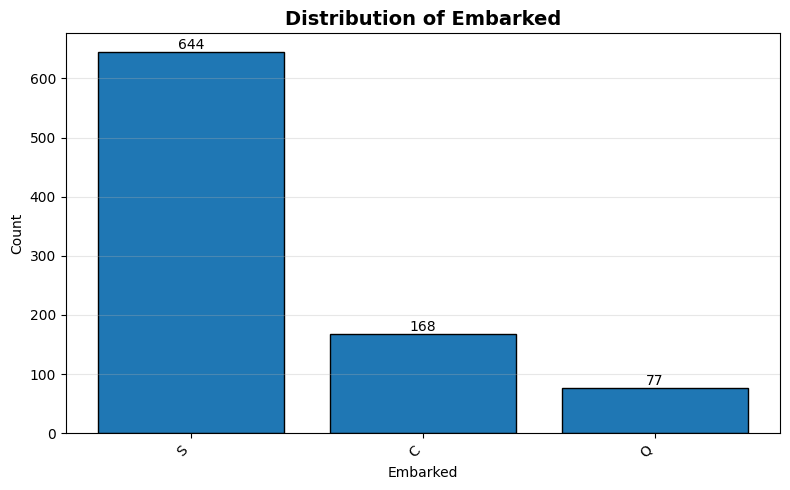

None


In [25]:
def create_categorical_distributions(df):
    print("\nDisplaying categorical distributions...")


    categorical_cols = df.select_dtypes(
        include=['object']
    ).columns


    # Remove columns with too many unique values
    categorical_cols = [
        col for col in categorical_cols
        if col not in ['Name', 'Ticket', 'Cabin']
    ]


    # Create separate plots for each feature
    for col in categorical_cols:

        value_counts = (
            df[col]
            .value_counts(dropna=True)
        )


        plt.figure(figsize=(8,5))


        bars = plt.bar(
            value_counts.index.astype(str),
            value_counts.values,
            edgecolor="black"
        )


        plt.title(
            f"Distribution of {col}",
            fontsize=14,
            fontweight="bold"
        )


        plt.xlabel(col)

        plt.ylabel(
            "Count"
        )


        plt.xticks(
            rotation=45,
            ha="right"
        )


        plt.grid(
            alpha=0.3,
            axis="y"
        )


        # Add values above bars
        for bar in bars:

            height = bar.get_height()

            plt.text(
                bar.get_x() + bar.get_width()/2,
                height,
                str(int(height)),
                ha="center",
                va="bottom"
            )


        plt.tight_layout()

        plt.show()

        plt.close()
output = create_categorical_distributions(df) 
print(output)

In [29]:
def analyze_correlations(df):
    print("CORRELATION ANALYSIS")
    
    # Select only numeric columns
    numeric_df = df.select_dtypes(include=[np.number])
    
    # Calculate correlation matrix
    correlation_matrix = numeric_df.corr()
    
    print("\nCorrelation Matrix:")
    print(correlation_matrix)
    
    # Find strong correlations with target variable (if exists)
    if 'Survived' in correlation_matrix.columns:
        print("\n\nCorrelations with Survival (Survived):")
        survival_corr = correlation_matrix['Survived'].sort_values(ascending=False)
        print(survival_corr)
        
        print("\n\nInterpretation:")
        for feature, corr_value in survival_corr.items():
            if feature != 'Survived':
                if abs(corr_value) >= 0.3:
                    strength = "MODERATE" if abs(corr_value) >= 0.3 else "WEAK"
                    direction = "POSITIVE" if corr_value > 0 else "NEGATIVE"
                    print(f"  • {feature}: {corr_value:.3f} ({strength} {direction})")
    
    return correlation_matrix
print( analyze_correlations(df))



CORRELATION ANALYSIS

Correlation Matrix:
             PassengerId  Survived    Pclass       Age     SibSp     Parch  \
PassengerId     1.000000 -0.005007 -0.035144  0.036847 -0.057527 -0.001652   
Survived       -0.005007  1.000000 -0.338481 -0.077221 -0.035322  0.081629   
Pclass         -0.035144 -0.338481  1.000000 -0.369226  0.083081  0.018443   
Age             0.036847 -0.077221 -0.369226  1.000000 -0.308247 -0.189119   
SibSp          -0.057527 -0.035322  0.083081 -0.308247  1.000000  0.414838   
Parch          -0.001652  0.081629  0.018443 -0.189119  0.414838  1.000000   
Fare            0.012658  0.257307 -0.549500  0.096067  0.159651  0.216225   

                 Fare  
PassengerId  0.012658  
Survived     0.257307  
Pclass      -0.549500  
Age          0.096067  
SibSp        0.159651  
Parch        0.216225  
Fare         1.000000  


Correlations with Survival (Survived):
Survived       1.000000
Fare           0.257307
Parch          0.081629
PassengerId   -0.005007
SibS


Generating correlation heatmap...


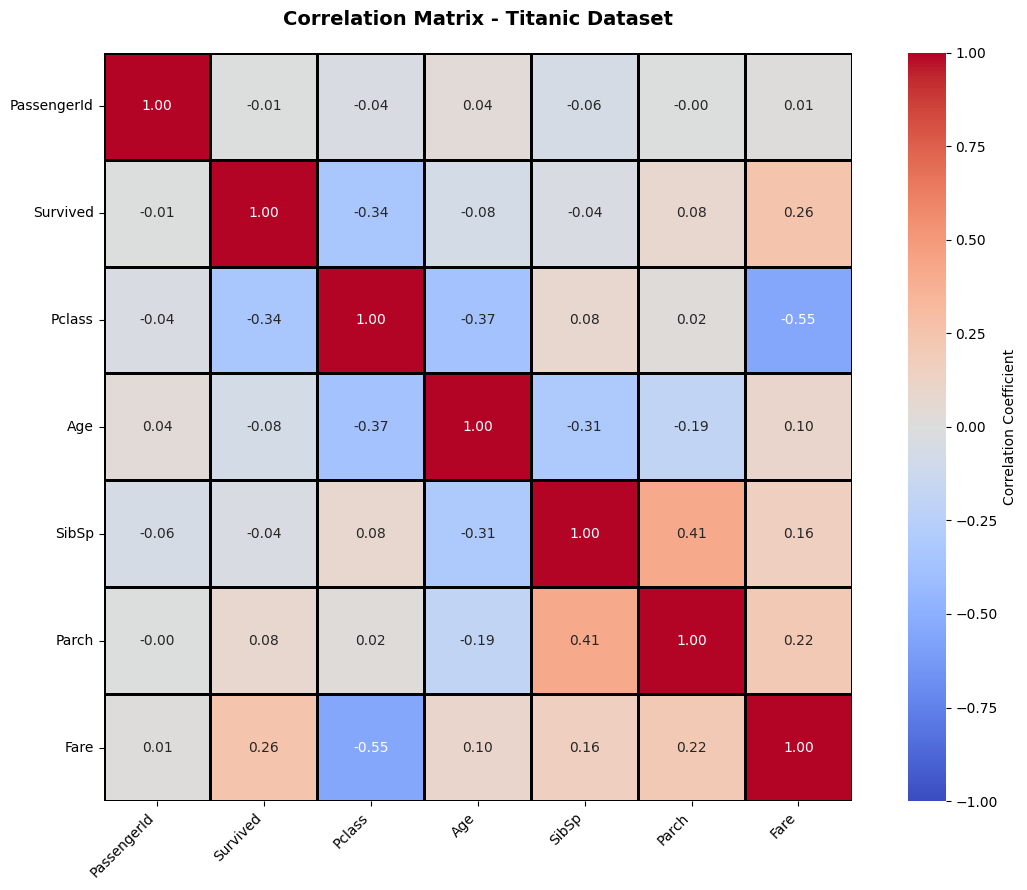

None


In [30]:
def create_correlation_heatmap(df, output_dir='outputs'):
    print("\nGenerating correlation heatmap...")
    
    # Select only numeric columns
    numeric_df = df.select_dtypes(include=[np.number])
    correlation_matrix = numeric_df.corr()
    
    # Create heatmap
    plt.figure(figsize=(12, 9))
    sns.heatmap(correlation_matrix, 
                annot=True,              
                fmt='.2f',               
                cmap='coolwarm',         
                center=0,                
                square=True,             
                linewidths=1,            
                linecolor='black',
                cbar_kws={'label': 'Correlation Coefficient'},
                vmin=-1, vmax=1)         
    
    plt.title('Correlation Matrix - Titanic Dataset', fontsize=14, fontweight='bold', pad=20)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    plt.close()

print(create_correlation_heatmap(df, output_dir='outputs'))
